Random Forest

In [2]:
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import pandas as pd

# Load your data
data = pd.read_csv('/content/blood_donation_dataset.csv')

# Define features and target variable
X = data[['Age', 'Gender', 'Weight', 'Height', 'Hemoglobin', 'Blood Type', 'Last Donation (months)', 'Total Number of Donations']].copy()  # Make a copy to avoid SettingWithCopyWarning
y = data['Donation Status']

# Encode 'Blood Type' if it's a categorical feature using .loc
X.loc[:, 'Blood Type'] = X['Blood Type'].astype('category').cat.codes

# Encode 'Gender' if it's a categorical feature using .loc
X.loc[:, 'Gender'] = data['Gender'].astype('category').cat.codes  # Assuming your dataset has a 'Gender' column

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a model (Random Forest example)
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# Save the trained model and scaler
pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

# Check the accuracy, precision, and recall
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)  # Change pos_label if necessary
recall = recall_score(y_test, y_pred, pos_label=1)  # Change pos_label if necessary
conf_matrix = confusion_matrix(y_test, y_pred)

# Print the results
print(f"\nModel accuracy:- {accuracy * 100:.2f}%")
print(f"\nModel precision:- {precision * 100:.2f}%")
print(f"\nModel recall:- {recall * 100:.2f}%")
print("\nConfusion Matrix:-")
print(conf_matrix)



Model accuracy:- 90.27%

Model precision:- 90.68%

Model recall:- 79.26%

Confusion Matrix:-
[[255  11]
 [ 28 107]]


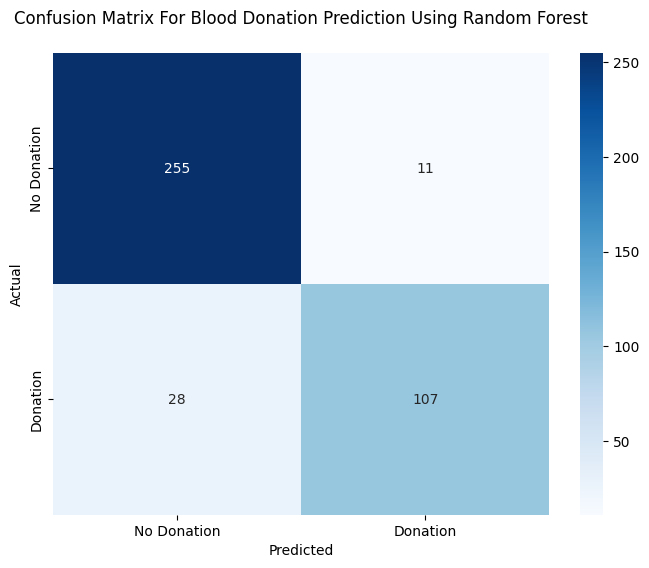

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Donation', 'Donation'], yticklabels=['No Donation', 'Donation'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix For Blood Donation Prediction Using Random Forest\n')
plt.show()


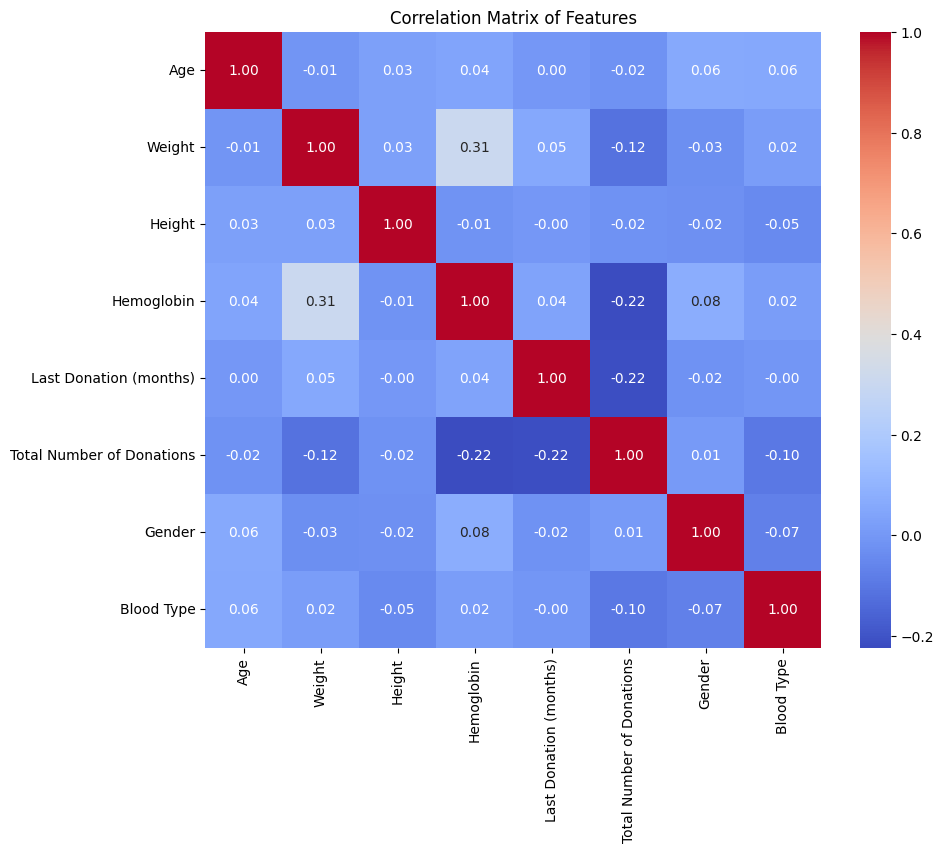

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
data = pd.read_csv('/content/blood_donation_dataset.csv')

# Select relevant features
features = ['Age', 'Weight', 'Height', 'Hemoglobin', 'Last Donation (months)', 'Total Number of Donations', 'Gender', 'Blood Type']

# Encode categorical features if necessary
data['Blood Type'] = data['Blood Type'].astype('category').cat.codes
data['Gender'] = data['Gender'].astype('category').cat.codes

# Calculate the correlation matrix
correlation_matrix = data[features].corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Features')
plt.show()


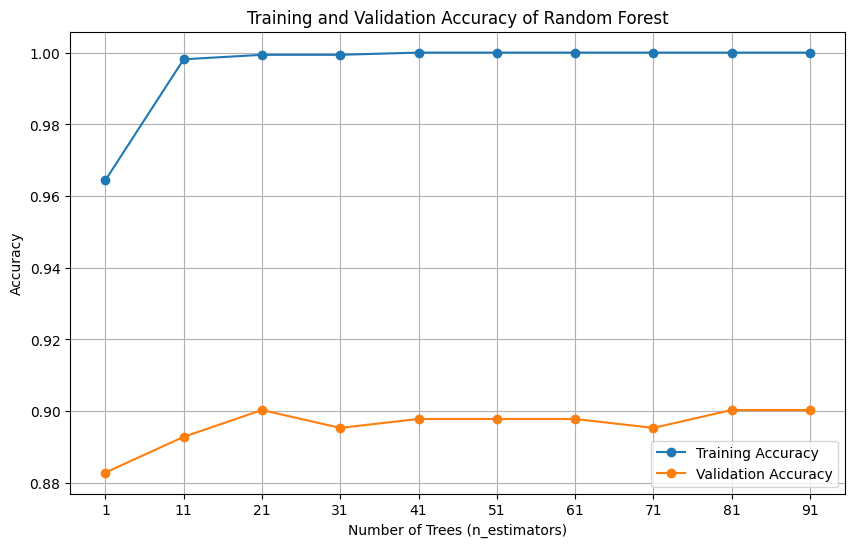

In [3]:
import pickle
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import pandas as pd

# Load your data
data = pd.read_csv('/content/blood_donation_dataset.csv')

# Define features and target variable
X = data[['Age', 'Gender', 'Weight', 'Height', 'Hemoglobin', 'Blood Type',
           'Last Donation (months)', 'Total Number of Donations']].copy()
y = data['Donation Status']

# Encode categorical features
X['Blood Type'] = X['Blood Type'].astype('category').cat.codes
X['Gender'] = X['Gender'].astype('category').cat.codes

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize variables to track training and validation accuracy
train_accuracies = []
val_accuracies = []

# Train Random Forest model and track accuracy
for n_estimators in range(1, 101, 10):  # Varying number of trees
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Calculate accuracies
    train_accuracy = accuracy_score(y_train, model.predict(X_train_scaled))
    val_accuracy = accuracy_score(y_test, model.predict(X_test_scaled))

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

# Plotting the training and validation accuracies
plt.figure(figsize=(10, 6))
plt.plot(range(1, 101, 10), train_accuracies, label='Training Accuracy', marker='o')
plt.plot(range(1, 101, 10), val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy of Random Forest')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.xticks(range(1, 101, 10))
plt.show()

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Performance metrics
models = ['Random Forest', 'SVM', 'Logistic Regression']
accuracies = [0.90, 0.79, 0.74]  # Replace with your actual accuracy values
precisions = [0.91, 0.78, 0.62]  # Replace with your actual precision values

# Set up the bar chart
x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plotting accuracy and precision
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='lightblue')
bars2 = ax.bar(x + width/2, precisions, width, label='Precision', color='salmon')

# Adding labels, title, and custom x-axis tick labels
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Adding data labels on top of the bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)

# Show the plot
plt.ylim(0, 1)  # Set the y-axis limit from 0 to 1
plt.show()


ModuleNotFoundError: No module named 'matplotlib'

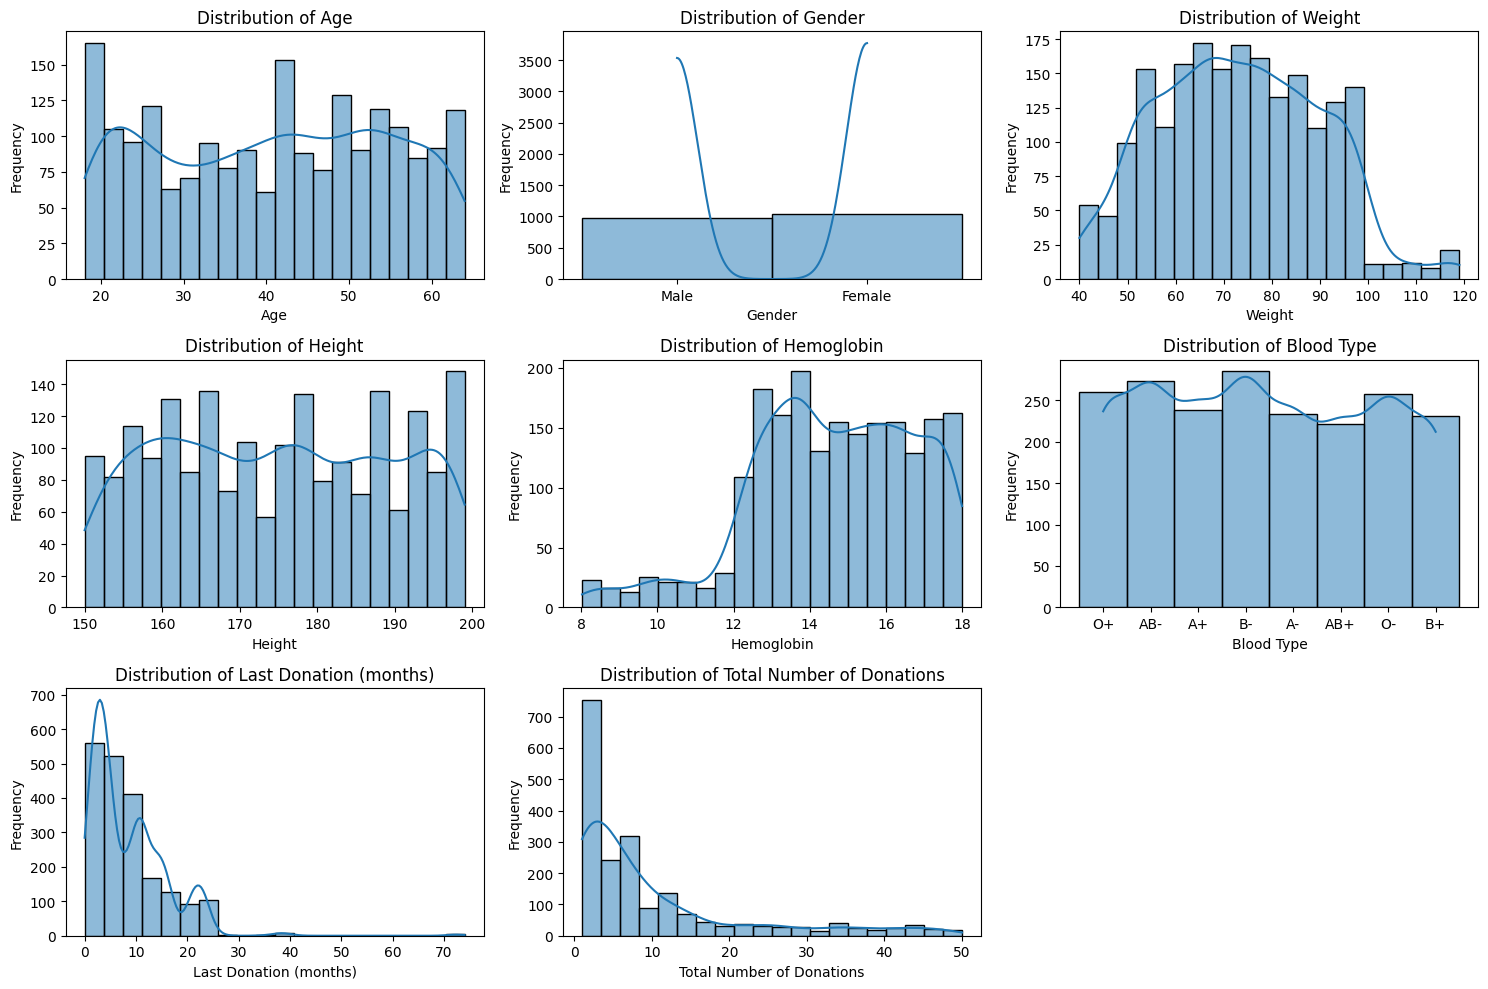

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
data = pd.read_csv('/content/blood_donation_dataset.csv')

# Define the features you want to plot
features = ['Age', 'Gender', 'Weight', 'Height', 'Hemoglobin',
            'Blood Type', 'Last Donation (months)', 'Total Number of Donations']

# Set up the figure size
plt.figure(figsize=(15, 10))

# Loop through each feature and create a subplot for each
for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)  # Create a 3x3 grid of subplots
    sns.histplot(data[feature], kde=True, bins=20)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


XGBoost

In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import joblib

# Load the dataset
data = pd.read_csv('/content/blood_donation_dataset.csv')

# Select features and target variable
x = data[['Age', 'Gender', 'Weight', 'Height', 'Hemoglobin', 'Blood Type', 'Last Donation (months)', 'Total Number of Donations']].copy()
y = data['Donation Status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train an XGBoost Classifier
model = XGBClassifier(random_state=42, n_estimators=200, learning_rate=0.1, max_depth=5)
model.fit(X_train, y_train)

# Predict and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f'Model accuracy with XGBoost:- {accuracy * 100:.2f}%\n')
print(f'Model precision:- {precision* 100:.2f}%\n')
print('Confusion Matrix:-')
print(conf_matrix)


Model accuracy with XGBoost:- 89.53%

Model precision:- 87.80%

Confusion Matrix:-
[[251  15]
 [ 27 108]]


SVM

In [ ]:
import pickle
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
import pandas as pd

# Load your data
data = pd.read_csv('/content/blood_donation_dataset.csv')

# Define features and target variable
X = data[['Age', 'Gender', 'Weight', 'Height', 'Hemoglobin', 'Blood Type', 'Last Donation (months)', 'Total Number of Donations']].copy()  # Make a copy to avoid SettingWithCopyWarning
y = data['Donation Status']

# Encode 'Blood Type' if it's a categorical feature using .loc
X.loc[:, 'Blood Type'] = X['Blood Type'].astype('category').cat.codes

# Encode 'Gender' if it's a categorical feature using .loc
X.loc[:, 'Gender'] = data['Gender'].astype('category').cat.codes  # Assuming your dataset has a 'Gender' column

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a model (SVM example)
model = SVC(random_state=42)
model.fit(X_train_scaled, y_train)

# Check the accuracy and precision
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)  # Change pos_label if necessary
conf_matrix = confusion_matrix(y_test, y_pred)

# Print the results
print(f"\nModel accuracy:- {accuracy * 100:.2f}%")
print(f"\nModel precision :- {precision* 100:.2f}%")
print("\nConfusion Matrix:-")
print(conf_matrix)



Model accuracy:- 79.30%

Model precision :- 78.26%

Confusion Matrix:-
[[246  20]
 [ 63  72]]


Logistic Regression

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
import joblib

# Load the dataset
data = pd.read_csv('/content/blood_donation_dataset.csv')

# Select features and target variable
X = data[['Age', 'Gender', 'Weight', 'Height', 'Hemoglobin', 'Blood Type', 'Last Donation (months)', 'Total Number of Donations']].copy()
y = data['Donation Status']

# One-hot encode categorical features (Gender and Blood Type)
X = pd.get_dummies(X, columns=['Gender', 'Blood Type'], drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=200)
model.fit(X_train, y_train)

# Predict and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print the results
print(f'Model accuracy with Logistic Regression:- {accuracy * 100:.2f}%\n')
print(f'Model precision:- {precision* 100:.2f}%\n')
print('Confusion Matrix:-')
print(conf_matrix)

Model accuracy with Logistic Regression:- 73.82%

Model precision:- 62.10%

Confusion Matrix:-
[[219  47]
 [ 58  77]]
